# Первая нейросеть на Keras


In [78]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_california_housing, fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.metrics import accuracy_score

import tensorflow as tf
from keras.layers import Dense, Flatten
from keras.models import Sequential
from keras.datasets import mnist
from keras.utils import to_categorical

## Сегодня на практическом занятии:

1. Обучим нейросеть на Keras для задачи регрессии (california housing)
2. Подготовим изображения к обучению нейросети
3. Обучим нейросеть на Keras для задачи классификации (MNIST)
4. Обучим нейросеть на Keras для задачи восстановления изображений

## Нейросеть для California housing

Будем работать с набором данным `fetch_california_housing` из `sklearn`.

In [3]:
data = fetch_california_housing()

X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = data['target']

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [5]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [6]:
data['target_names']

['MedHouseVal']

#### 1.1. Разбейте данные на обучение и тест

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [11]:
mms = MinMaxScaler()
X_train_norm = mms.fit_transform(X_train)

In [12]:
X_test_norm = mms.fit_transform(X_test)

In [13]:
pd.DataFrame(X_train_norm, columns=data['feature_names']).head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,0.190322,0.627451,0.029278,0.026601,0.064380,0.002414,0.017021,0.729084
1,0.228452,0.941176,0.025419,0.027968,0.036744,0.000842,0.129787,0.616534
2,0.252162,0.058824,0.033732,0.025759,0.025561,0.001634,0.224468,0.385458
3,0.099488,0.686275,0.022081,0.027683,0.039659,0.002657,0.014894,0.721116
4,0.210638,0.823529,0.038147,0.031651,0.024412,0.001294,0.450000,0.453187


In [14]:
y_train.shape, y_test.shape

((16512,), (4128,))

#### 1.2. Создайте архитектуру для этой задачи

In [16]:
model = Sequential([
    Dense(1, input_shape=(8,), activation='linear')
])

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

#### 1.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'sgd'

In [18]:
model.compile(
    optimizer='sgd',
    loss='mse',
    metrics=['mae']
)

#### 1.4. Обучите нейросеть

Выберите нужное количество эпох.


In [19]:
model.fit(X_train_norm, y_train, epochs=20)

Epoch 1/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.8975 - mae: 1.0472
Epoch 2/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1081 - mae: 0.8358
Epoch 3/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.9706 - mae: 0.7784
Epoch 4/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8575 - mae: 0.7281
Epoch 5/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7808 - mae: 0.6891
Epoch 6/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7227 - mae: 0.6606
Epoch 7/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6922 - mae: 0.6357
Epoch 8/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6655 - mae: 0.6224
Epoch 9/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6507 - mae: 0.6118
Epoch 10/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6313 - mae: 0.5997
Epoch 11/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5987 - mae: 0.5851
Epoch 12/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5849 - mae: 0.5765
Epoch 13/20
516/516 ━━━━━

#### 1.5. Сделайте вывод, хорошо ли модель обучается?

Если модель обучается плохо, можете внести изменения в работу.

In [ ]:
# Ваш вывод здесь


#### 1.6. Сделайте предсказания на тестовых данных

In [20]:
predicts = model.predict(X_test_norm)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [21]:
pd.DataFrame({
    'true': np.squeeze(y_test),
    'pred': np.squeeze(predicts)
}).head(10)


,true,pred
0,0.47700,0.919249
1,0.45800,1.630829
2,5.00001,2.391862
3,2.18600,2.761324
4,2.78000,2.335139
5,1.58700,2.123153
6,1.98200,2.697952
7,1.57500,2.173659
8,3.40000,2.167866
9,4.46600,4.065914


#### 1.7. Посчитайте метрику качества на тестовых данных

Доп информация по метрикам [здесь](https://youtu.be/vh2smjQyhp8)

In [22]:
# mae
mean_absolute_error(y_test, predicts)

0.5616280398006495

In [23]:
#mse
mean_squared_error(y_test, predicts)

0.5849178856201918

In [24]:
#rmse
root_mean_squared_error(y_test, predicts)

0.7647992453057153

In [25]:
#r2
r2_score(y_test, predicts)

0.5536371504372712

## 2. Нейросеть для MNIST

Будем работать с набором данных `MNIST` из `keras`.

In [36]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

### 2.1. Отрисуйте несколько примеров из обучения

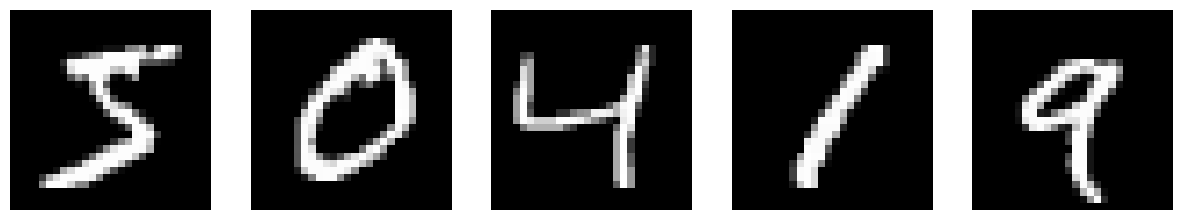

In [37]:
fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(X_train[i], cmap='gray')
    ax[i].axis('off')


### 2.2. Подготовка данных

#### 2.2.1. Возьмите для обучения только два класса (3 и 8), чтобы сделать задачу бинарной классификации.

In [38]:
idxs = np.where((y_train == 3) | (y_train == 8))
y_train = y_train[idxs]

In [39]:
X_train = X_train[idxs]

#### 2.2.2. И тоже самое сделайте для теста

In [41]:
idxs = np.where((y_test == 3) | (y_test == 8))
y_test = y_test[idxs]

In [42]:
X_test = X_test[idxs]

#### 2.2.3. Отрисуйте несколько изображений из новых данных


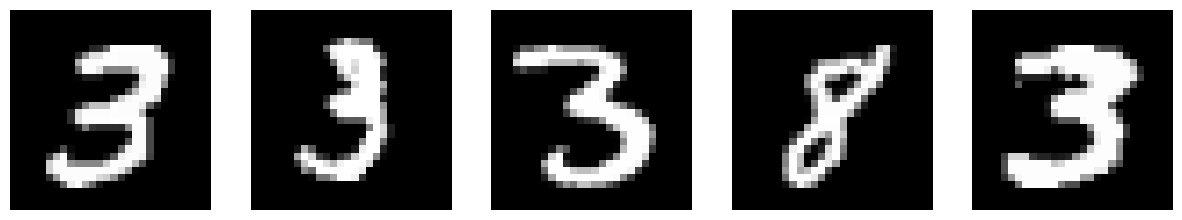

In [43]:
fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(X_train[i], cmap='gray')
    ax[i].axis('off')

#### 2.2.4. Нормируйте данные

In [44]:
X_train = X_train / 255.0
X_test = X_test / 255.0

#### 2.2.5. Преобразуйте целевые значения в бинарный вид

При этом еще нужно вначале перевести класс 3 и 8 в 0 и 1, только при таких метках класса сетка будет обучаться правильно.

In [45]:
y_train[:5]


array([3, 3, 3, 8, 3], dtype=uint8)

In [ ]:
y_train_bin = np.where(y_train == 3, 0, y_train)

In [49]:
y_train_bin = np.where(y_train_bin == 8, 1, y_train_bin)

y_train_bin[:5]

array([0, 0, 0, 1, 0], dtype=uint8)

In [50]:
y_test_bin = np.where(y_test == 3, 0, y_test)
y_test_bin = np.where(y_test_bin == 8, 1, y_test_bin)
y_test_bin[:5]

array([0, 0, 0, 0, 0], dtype=uint8)

In [52]:
y_train_cat = to_categorical(y_train_bin)
y_test_cat = to_categorical(y_test_bin)

y_train_cat[:5]

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.]])

### 2.3. Создайте архитектуру для этой задачи

In [53]:
print(X_train[0].shape)

(28, 28)


In [67]:
tf.random.set_seed(9)

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(32, activation='relu'),
    Dense(2, activation='sigmoid')
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,186 (98.38 KB)

 Trainable params: 25,186 (98.38 KB)

 Non-trainable params: 0 (0.00 B)

### 2.4. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'sgd'

In [68]:
model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### 2.5. Обучите нейросеть

Выберите нужное количество эпох.


In [69]:
model.fit(X_train, y_train_cat, epochs=10)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7981 - loss: 0.5114
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9349 - loss: 0.2195
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9460 - loss: 0.1645
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9524 - loss: 0.1434
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9562 - loss: 0.1321
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9590 - loss: 0.1248
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9607 - loss: 0.1196
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9624 - loss: 0.1156
Epoch 9/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9632 - loss: 0.1122
Epoch 10/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9640 - loss: 0.1094


### 2.6. Сделайте предсказания на тестовых данных

In [71]:
preds = model.predict(X_test)
preds

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[7.4587274e-01, 2.2373196e-01],
       [9.9916154e-01, 9.7848242e-04],
       [9.8819619e-01, 1.8125299e-02],
       ...,
       [5.9596127e-01, 3.9402604e-01],
       [4.1936941e-02, 9.4821203e-01],
       [9.9996620e-01, 3.8560953e-05]], shape=(1984, 2), dtype=float32)

In [72]:
preds_cls = preds.argmax(axis=1)
preds_cls

array([0, 0, 0, ..., 0, 1, 0], shape=(1984,))

### 2.7. Посчитайте метрику качества на тестовых данных

По метрикам можете повторить эти занятия по [ссылке](https://youtube.com/playlist?list=PLkJJmZ1EJno6CLyvD4DHc32Fed6cPBHje)

In [76]:
print(f"test acc: {accuracy_score(y_test_bin, preds_cls)*100:.2f}% ({(y_test_bin == preds_cls).sum()} out of {y_test_bin.shape[0]})")

test acc: 96.77% (1920 out of 1984)


## 3. Нейросеть для восстановления изображения

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

In [89]:
data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

In [90]:
train.shape

(320, 4096)

Сейчас изображение - это вектор 4096.

### 3.1. Работа с данными

#### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [108]:
train = train.reshape((320, 64, 64))

In [109]:
train.shape

(320, 64, 64)

In [112]:
test.shape

(80, 4096)

In [113]:
test = test.reshape(80, 64, 64)

#### 3.1.2. Отрисуйте несколько примеров

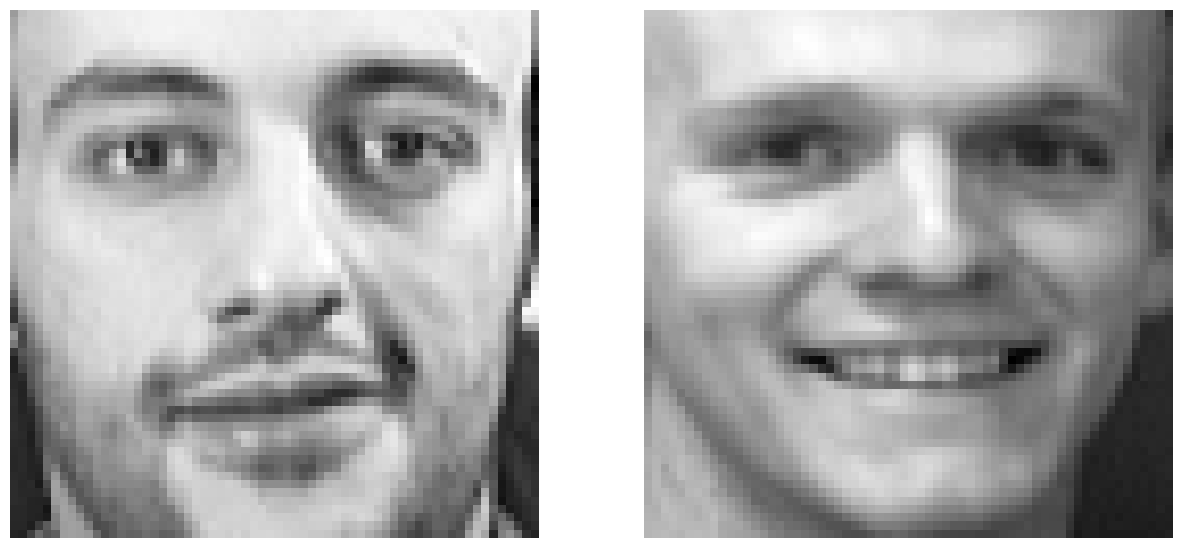

In [110]:
fig, ax = plt.subplots(1, 2, figsize=(15, 10))

for i in range(2):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')


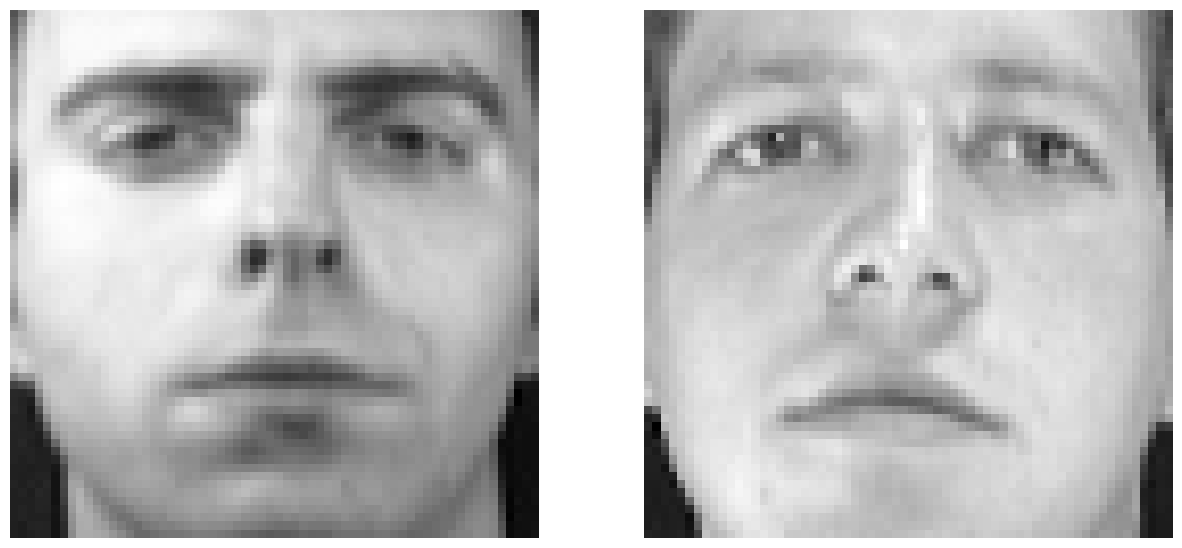

In [114]:
fig, ax = plt.subplots(1, 2, figsize=(15, 10))

for i in range(2):
    ax[i].imshow(test[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [115]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [116]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

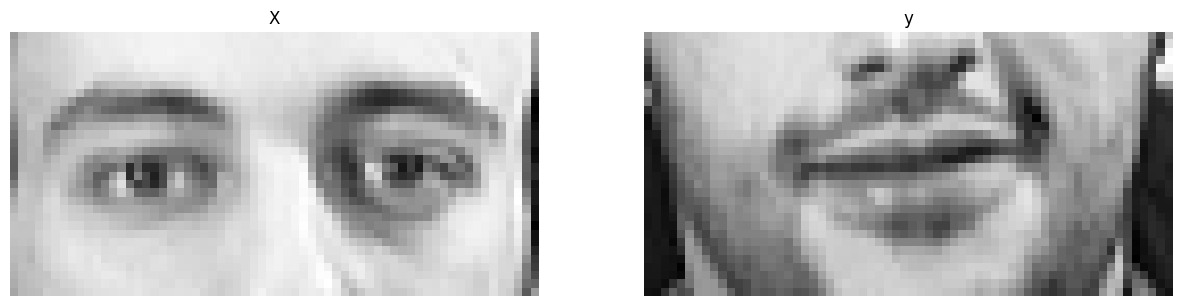

In [117]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

#### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [ ]:
y_train.shape

(320, 32, 64)

In [119]:
y_train = y_train.reshape((320, 2048))
y_train.shape

(320, 2048)

In [120]:
y_test = y_test.reshape((80, -1))
y_test.shape

(80, 2048)

### 3.2. Создайте архитектуру для этой задачи

In [133]:
tf.random.set_seed(9)

model = Sequential([
    Flatten(input_shape=(32, 64)),
    Dense(1024, activation='relu'),
    Dense(1024, activation='relu'),
    Dense(32 * 64, activation='linear')
])

model.summary()


/home/andrew/netol_classes/.venv/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2048)           │     2,099,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,246,976 (20.02 MB)

 Trainable params: 5,246,976 (20.02 MB)

 Non-trainable params: 0 (0.00 B)

### 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [135]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

### 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [136]:
model.fit(X_train, y_train, epochs=300)


Epoch 1/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 0.1779 - mae: 0.3209
Epoch 2/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 0.0258 - mae: 0.1275
Epoch 3/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0201 - mae: 0.1118
Epoch 4/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0188 - mae: 0.1076
Epoch 5/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - loss: 0.0175 - mae: 0.1037
Epoch 6/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.0174 - mae: 0.1029
Epoch 7/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0162 - mae: 0.0988
Epoch 8/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0156 - mae: 0.0966
Epoch 9/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.0153 - mae: 0.0951
Epoch 10/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0147 - mae: 0.0931
Epoch 11/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - loss: 0.0150 - mae: 0.0940
Epoch 12/300
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0144 - mae: 0.0919
Epoch 13/300


### 3.5. Сделайте предсказания на тестовых данных

In [137]:
preds = model.predict(X_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


### 3.6. Посчитайте метрику качества на тестовых данных

Доп информация по метрикам [здесь](https://youtu.be/vh2smjQyhp8)

In [139]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(preds, y_test)

0.07099916785955429

### 3.7. Поменяйте размерность предсказанных векторов в двумерное изображение

In [140]:
preds.shape

(80, 2048)

In [141]:
pred_test = preds.reshape(preds.shape[0], 32, 64)
pred_test.shape

(80, 32, 64)

In [144]:
y_test = y_test.reshape(y_test.shape[0], 32, 64)

А сейчас отрисуем все предсказания.

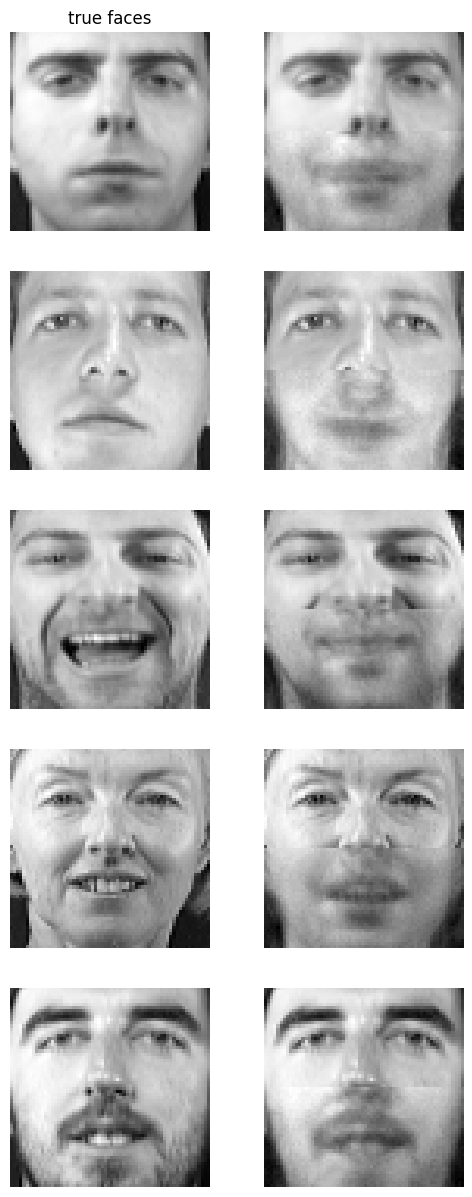

In [145]:
n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.vstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], pred_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )

## Резюме

Сегодня на практическом занятии:

1. Обучили нейросеть на Keras для задачи регрессии (california housing)
2. Подготовили изображения к обучению нейросети
3. Обучили нейросеть на Keras для задачи классификации (MNIST)
4. Обучили нейросеть на Keras для задачи восстановления изображений

**Муррр** ♥